# Positive-latent multi-output GP and sensor-noise sensitivity

This experiment replaces the unconstrained Gaussian latent fields with

$$H_i=\operatorname{softplus}(g_i),\qquad
H_s=\operatorname{softplus}(g_s),$$

where $g_i$ and $g_s$ are variational Gaussian processes. The positive fields
enter the same physical observation equation $y=H[H_i,H_s]^T+\epsilon$ during
training. This is not post-hoc clipping: every latent sample is positive by
construction.

Four sensor-noise settings were pre-specified and evaluated using five
contiguous spatial folds on March 8. The selection score gives each sensor
equal relative weight by dividing its RMSE by the point-interpolation baseline.
The chosen noise setting is then frozen and evaluated on March 29, whose 15-day
window does not overlap March 8.


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

summary = json.load(open('positive_gp_noise_sensitivity_summary.json'))
pred = np.genfromtxt(
    '../results/positive_gp_noise_sensitivity_predictions.csv', delimiter=',', names=True,
    dtype=None, encoding='utf-8'
)
selected = summary['selected_noise_config']
print('Selected configuration:', selected)
print('Frozen sensor noise (m):', summary['selected_sigma_m'])


Selected configuration: is2_heavy
Frozen sensor noise (m): {'CS2': 0.05, 'IS2': 0.02}


## March 8 development-window noise sensitivity


cs2_heavy  sigma=(0.02, 0.04) m  CS2=0.0780 m  IS2=0.1062 m  relative score=1.076
balanced   sigma=(0.03, 0.03) m  CS2=0.0708 m  IS2=0.1058 m  relative score=1.018
nominal    sigma=(0.03, 0.02) m  CS2=0.0674 m  IS2=0.1042 m  relative score=0.983
is2_heavy  sigma=(0.05, 0.02) m  CS2=0.0638 m  IS2=0.1050 m  relative score=0.959


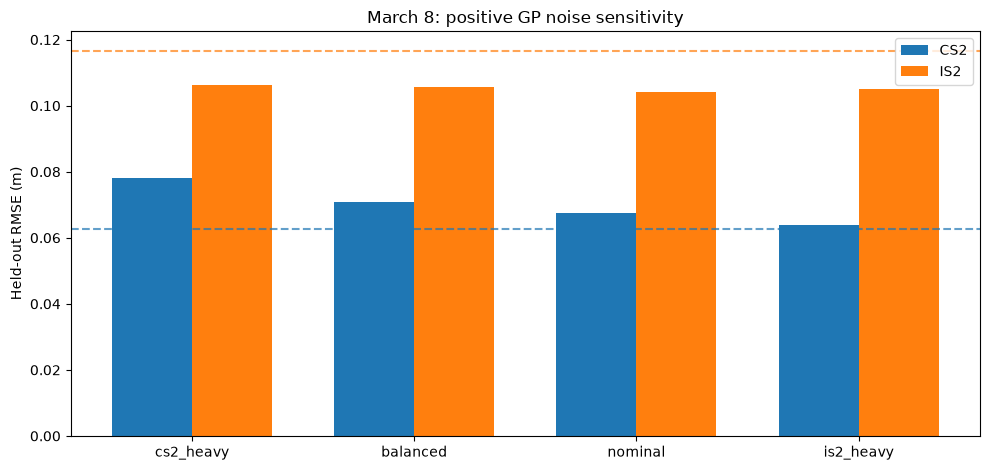

In [2]:
sensitivity = summary['development_noise_sensitivity']
for name, values in sensitivity.items():
    print(
        f"{name:10s} sigma=({values['sigma_cs2_m']:.2f}, {values['sigma_is2_m']:.2f}) m  "
        f"CS2={values['CS2_RMSE_m']:.4f} m  IS2={values['IS2_RMSE_m']:.4f} m  "
        f"relative score={values['relative_score']:.3f}"
    )

names = list(sensitivity)
x = np.arange(len(names))
width = 0.36
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(x-width/2, [sensitivity[n]['CS2_RMSE_m'] for n in names], width, label='CS2')
ax.bar(x+width/2, [sensitivity[n]['IS2_RMSE_m'] for n in names], width, label='IS2')
ax.axhline(summary['development_baseline']['CS2_RMSE_m'], color='C0', ls='--', alpha=.7)
ax.axhline(summary['development_baseline']['IS2_RMSE_m'], color='C1', ls='--', alpha=.7)
ax.set_xticks(x, names)
ax.set_ylabel('Held-out RMSE (m)')
ax.set_title('March 8: positive GP noise sensitivity')
ax.legend()
plt.tight_layout()


## Comparison with earlier models


In [3]:
comparison = np.genfromtxt(
    '../results/positive_gp_method_comparison.csv', delimiter=',', names=True,
    dtype=None, encoding='utf-8'
)
for window in ['March_8', 'March_29']:
    print(window)
    mask = comparison['window'] == window
    for method in np.unique(comparison['method'][mask]):
        row = comparison[mask & (comparison['method'] == method)]
        values = {sensor: float(row['RMSE_m'][row['sensor'] == sensor][0]) for sensor in ['CS2', 'IS2']}
        print(f"  {method:18s} CS2={values['CS2']:.4f} m  IS2={values['IS2']:.4f} m")


March_8
  Hard-positive DRF  CS2=0.0905 m  IS2=0.1231 m
  Nested linear GP   CS2=0.0805 m  IS2=0.1014 m
  Point + linear     CS2=0.0628 m  IS2=0.1167 m
  Positive GP        CS2=0.0638 m  IS2=0.1050 m
March_29
  Nested linear GP   CS2=0.0809 m  IS2=0.1257 m
  Point + linear     CS2=0.0527 m  IS2=0.1465 m
  Positive GP        CS2=0.0703 m  IS2=0.1211 m


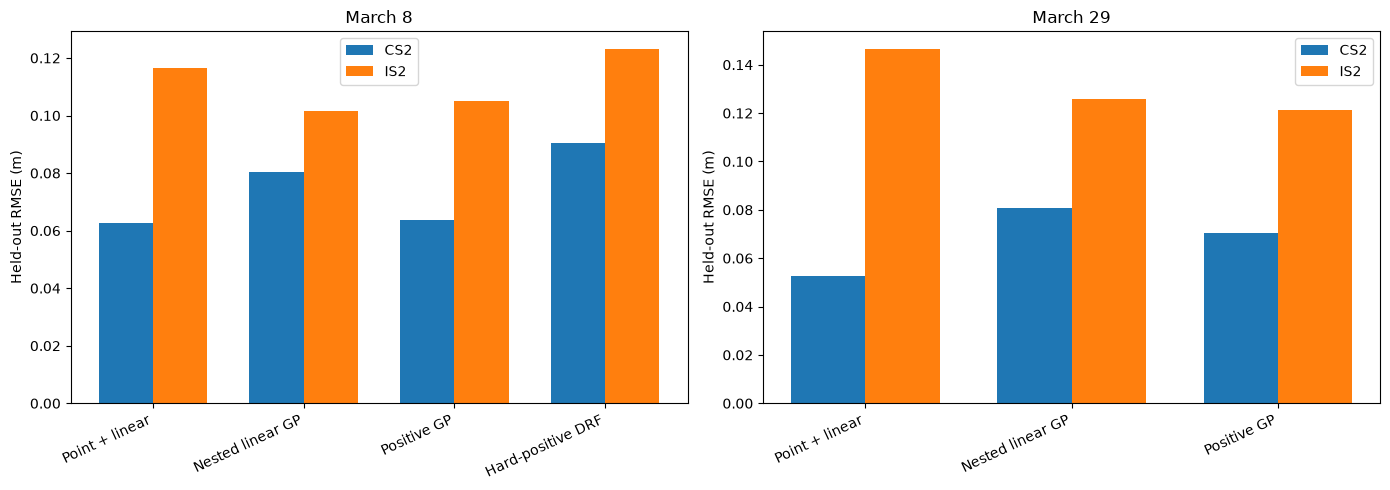

In [4]:
windows = ['March_8', 'March_29']
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for ax, window in zip(axs, windows):
    mask = comparison['window'] == window
    methods = list(dict.fromkeys(comparison['method'][mask].tolist()))
    x = np.arange(len(methods))
    for offset, sensor in [(-0.18, 'CS2'), (0.18, 'IS2')]:
        values = [float(comparison['RMSE_m'][mask & (comparison['method']==m) & (comparison['sensor']==sensor)][0]) for m in methods]
        ax.bar(x+offset, values, width=.36, label=sensor)
    ax.set_xticks(x, methods, rotation=25, ha='right')
    ax.set_ylabel('Held-out RMSE (m)')
    ax.set_title(window.replace('_', ' '))
    ax.legend()
plt.tight_layout()


## Positive latent diagnostics and held-out transects


March_8 {'Hi range': (1.0795810597954725, 2.632073716708871), 'Hs range': (0.09338559983084842, 0.1968647791866713), 'negative Hi': 0, 'negative Hs': 0}
March_29 {'Hi range': (1.0859717654480807, 3.3131382260359366), 'Hs range': (0.09957807657269602, 0.19081564093597952), 'negative Hi': 0, 'negative Hs': 0}


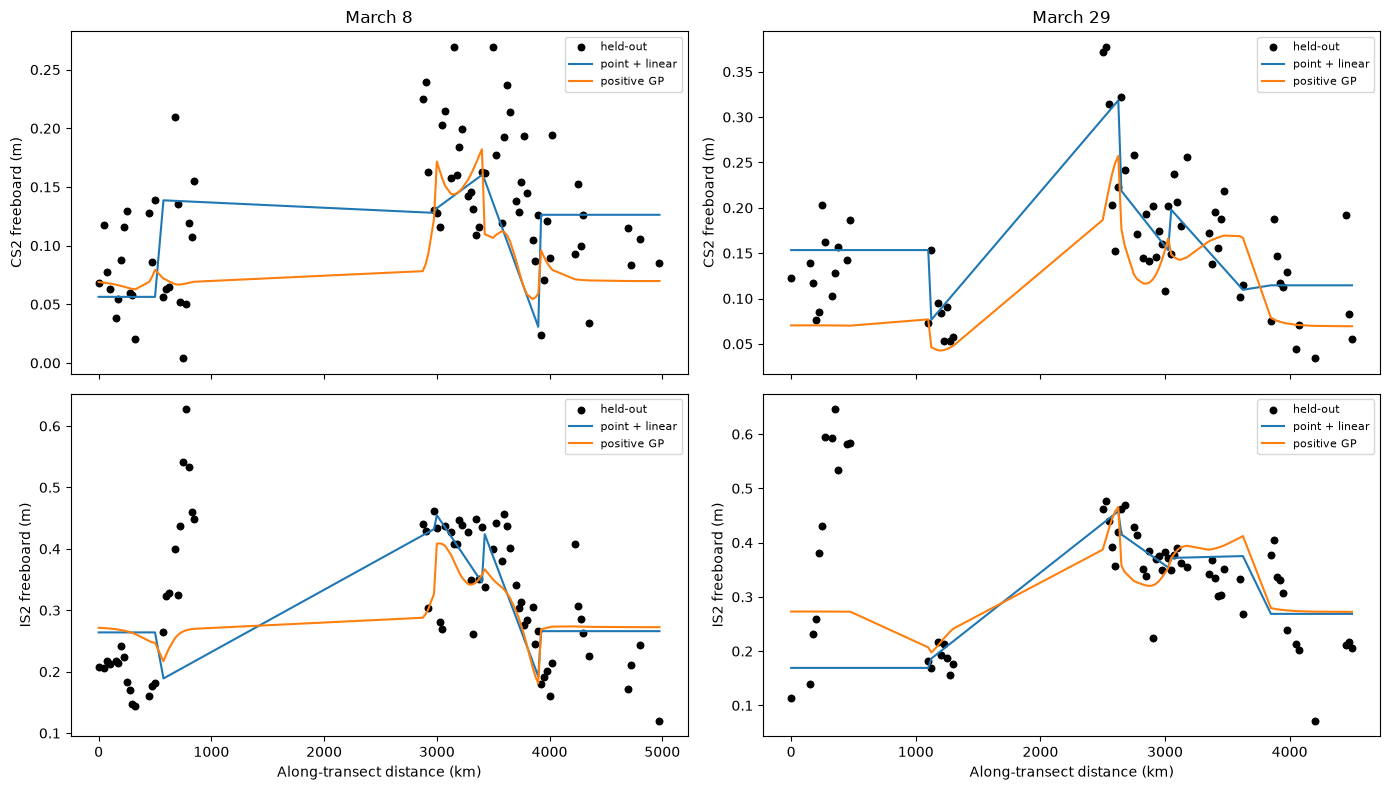

In [5]:
selected_rows = pred[pred['noise_config'] == selected]
for window in ['March_8', 'March_29']:
    d = selected_rows[selected_rows['window'] == window]
    print(window, {
        'Hi range': (float(d['positive_gp_Hi_m'].min()), float(d['positive_gp_Hi_m'].max())),
        'Hs range': (float(d['positive_gp_Hs_m'].min()), float(d['positive_gp_Hs_m'].max())),
        'negative Hi': int((d['positive_gp_Hi_m'] < 0).sum()),
        'negative Hs': int((d['positive_gp_Hs_m'] < 0).sum()),
    })

fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharex='col')
for col, window in enumerate(['March_8', 'March_29']):
    d = selected_rows[selected_rows['window'] == window]
    order = np.argsort(d['distance_km'])
    for row, sensor in enumerate(['cs2', 'is2']):
        ax = axs[row, col]
        ax.scatter(d['distance_km'][order], d[f'actual_{sensor}_m'][order], s=22, color='black', label='held-out')
        ax.plot(d['distance_km'][order], d[f'point_pred_{sensor}_m'][order], label='point + linear')
        ax.plot(d['distance_km'][order], d[f'positive_gp_pred_{sensor}_m'][order], label='positive GP')
        ax.set_ylabel(sensor.upper() + ' freeboard (m)')
        ax.set_title(window.replace('_', ' ') if row == 0 else '')
        ax.legend(fontsize=8)
    axs[-1, col].set_xlabel('Along-transect distance (km)')
plt.tight_layout()


## Evidence-based interpretation

- The selected setting treats CS2 as noisier than IS2
  ($\sigma_{CS2}=0.05$ m, $\sigma_{IS2}=0.02$ m). This is an empirical model
  weighting, not yet a mission-product uncertainty claim.
- On March 8, the positive GP nearly matches the interpolation baseline for
  CS2 (0.0638 vs 0.0628 m) and improves IS2 (0.1050 vs 0.1167 m).
- Relative to the nested unconstrained GP, the positive model greatly improves
  March 8 CS2 while giving up a small amount of its IS2 gain.
- With the noise setting frozen, March 29 reproduces the IS2 improvement
  (0.1211 vs 0.1465 m). CS2 remains worse than interpolation (0.0703 vs
  0.0527 m), but is better than the unconstrained nested GP (0.0809 m).
- All reported positive-GP ice and snow posterior means are positive, and the
  softplus parameterisation guarantees positive latent samples as well.
- The positive GP outperforms the current hard-positive DRF on both March 8
  freeboards, but neither complex model universally beats the simple baseline.

This supports a careful dissertation claim: physical constraints and
sensor-specific weighting materially improve the multi-output GP, especially
for IS2 and relative to DRF, but the CS2 interpolation baseline remains
competitive. The next scientific requirement is to justify sensor noise from
product uncertainty information and validate $H_i/H_s$ against independent
measurements rather than freeboard reconstruction alone.
